In [20]:
######### LIBRARIES ############
# RICORDA DI ELIMINARE TUTTE LIBRERIE CHE NON UTILIZZI
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

In [21]:
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [22]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)

reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

permutation = np.random.permutation(len(reaction_HF_test))
n_HF = 15
reaction_HF = reaction_HF_test[permutation][0:n_HF]


U_HF_test = U_HF_test[:, -1, 44,44]

U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

U_HF = U_HF_test[permutation][0:n_HF]


In [23]:
U_LF_list = []
U_HF_list = []

NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoHF = 3000  # number of epochs for second NN: NN_HF
Nlf = 30

#HF_data = [5, 10, 15]
#HF_data_str = [str(num) for num in HF_data]
r2_HF_df = pandas.DataFrame()  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame()  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(
)  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame()  # dataframe which stores LF MSE

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.02370238349542126
R^2: 0.8098806459449803
2/2 [==============================] - 0s 0s/step
Elapsed time:  18.211047699995106

HF Model:
Test MSE: 0.1794197449019044
R^2: -0.5849970628194345
2/2 [==============================] - 0s 16ms/step


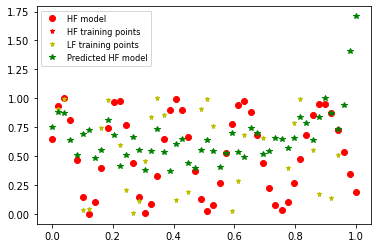

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.14043528102713684
R^2: -0.1287960621015043
2/2 [==============================] - 0s 3ms/step
Elapsed time:  26.336418799997773

HF Model:
Test MSE: 0.10845215756771631
R^2: 0.04193180468937163
2/2 [==============================] - 0s 0s/step


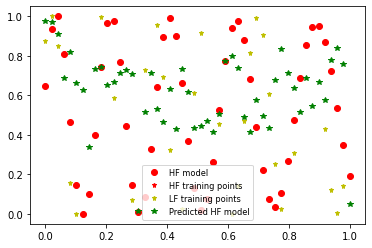

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 5.533218018737487
R^2: -42.3726982119749
2/2 [==============================] - 0s 16ms/step
Elapsed time:  17.699098400000366

HF Model:
Test MSE: 1.2613398871306722
R^2: -10.142697908818018
2/2 [==============================] - 0s 0s/step


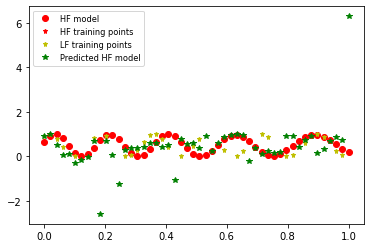

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 17ms/step

LF Model:
Test MSE: 0.12210248941991286
R^2: -0.005013234354503071
2/2 [==============================] - 0s 875us/step
Elapsed time:  18.221053999994183

HF Model:
Test MSE: 0.127798321793716
R^2: -0.12897253748209292
2/2 [==============================] - 0s 8ms/step


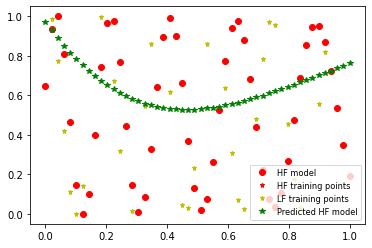

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 6.30922181629462
R^2: -49.62344745107808
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.84822699999495

HF Model:
Test MSE: 1.0312921931707344
R^2: -8.11045268723307
2/2 [==============================] - 0s 17ms/step


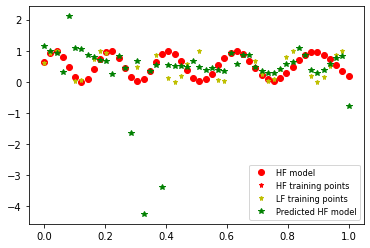

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.11514621691834863
R^2: -0.01667662489504429
2/2 [==============================] - 0s 0s/step
Elapsed time:  18.204239600003348

HF Model:
Test MSE: 0.12718054446097118
R^2: -0.12351508206985651
2/2 [==============================] - 0s 3ms/step


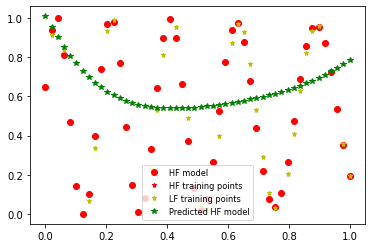

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.012853077484636289
R^2: 0.8906834449499842
2/2 [==============================] - 0s 4ms/step
Elapsed time:  17.48469290000503

HF Model:
Test MSE: 0.16709613323144926
R^2: -0.4761300687677035
2/2 [==============================] - 0s 3ms/step


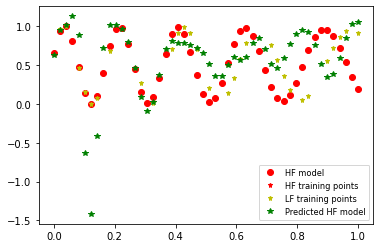

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.007771226053508772
R^2: 0.9342792383178671
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.8996746000048

HF Model:
Test MSE: 0.08919737152544764
R^2: 0.21202891043934513
2/2 [==============================] - 0s 16ms/step


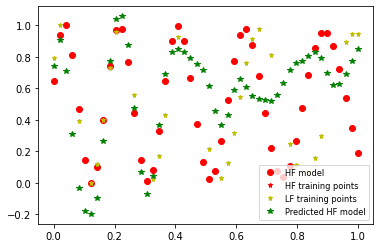

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.04072052833061682
R^2: 0.6731432226175257
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.888335700001335

HF Model:
Test MSE: 0.15437938533967036
R^2: -0.36379010268367606
2/2 [==============================] - 0s 0s/step


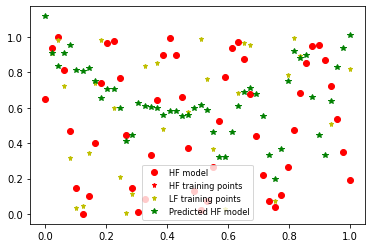

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.11372874482413975
R^2: 0.0002890033185022345
2/2 [==============================] - 0s 0s/step
Elapsed time:  21.510660400002962

HF Model:
Test MSE: 0.12717968246571468
R^2: -0.12350746718917271
2/2 [==============================] - 0s 0s/step


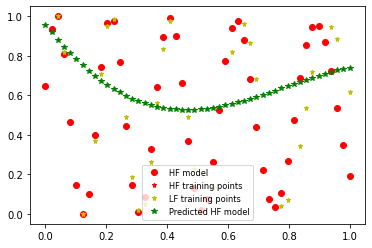

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0032179746704912356
R^2: 0.9726799914948577
2/2 [==============================] - 0s 0s/step
Elapsed time:  19.092863799989573

HF Model:
Test MSE: 0.02016509438134985
R^2: 0.8218612149772545
2/2 [==============================] - 0s 5ms/step


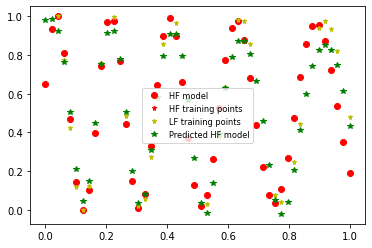

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.005396804746014127
R^2: 0.953377328414431
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.911147799997707

HF Model:
Test MSE: 0.023848496313422098
R^2: 0.7893219799743851
2/2 [==============================] - 0s 0s/step


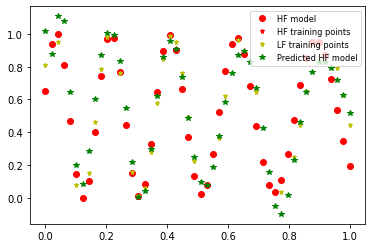

        10       28       46
0 -0.12897  0.21203  0.78932
       10      28       46
0  0.1278  0.0892  0.02385


In [24]:
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)
        
        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
       

        U_train_LF = U_LF_test[permutation][0:Nlf]


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )

        test_mse_HF_list = []
        test_mse_LF_list = []

        r2_HF_list = []
        r2_LF_list = []
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 

        
        modelLF = getModel(bestLF_params, "LF")  # ann_functions
        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        #        histLF = modelLF.fit(Young_LF_norm[:,0], U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
        # attenzione -> QUANDO LO FARAI IN PIU DIMENSIONI DI INPUT QUESTA PARTE E' DA SCRIVERE TENENDO CONTO DELLE DIMNSIONI EFFETTIVE DELLA MATRICE DI INPUT, DATO CHE NON POTRAI TAGLIARE ALL'INIZIO
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)

        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")
        
        start = perf_counter()
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_HF

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_HF

        name = "2step"
        K.clear_session()
        # best parameters obtained by HPO:

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
        
        
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            verbose=0,
            validation_freq=20,
        )

        UHF = finalModel.predict(reaction_test_in)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
        print("\nHF Model:")

        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")
        
        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_in),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()

        r2_LF_df[str(Discretizations[m])] = r2_LF_list
        r2_HF_df[str(Discretizations[m])] = r2_HF_list

        mse_LF_df[str(Discretizations[m])] = test_mse_LF_list
        mse_HF_df[str(Discretizations[m])] = test_mse_HF_list
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



In [26]:
print(r2_HF_df)

         10        28        46
0 -0.128973  0.212029  0.789322


In [27]:
os.makedirs("MF_LF_30_5000_HF_15_3000_new_activation")

r2_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_new_activation/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_new_activation/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_new_activation/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_new_activation/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_30_5000_HF_15_3000_new_activation/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_30_5000_HF_15_3000_new_activation/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)